## İş Uygulaması: ML Modelinin Başarı Testi (AB Testi)

- **Problem:**
  Bir ML projesine yatırım yapılmış. Ürettiği tahminler neticesinde oluşan gelir ile eski sistemin ürettiği gelirler karşılaştırılıp anlamlı farklılık olup olmadığı test edilmek isteniyor.

- **Detaylar:**
  - Model geliştirilmiş ve web sitesine entegre edilmiş.
  - Site kullanıcıları belirli bir kurala göre ikiye bölünmüş olsun.
  - A grubuna eski sistemin önerdiği ürünler, B grubuna yeni sistemin önerdiği ürünler gösteriliyor.
  - Gelir anlamında anlamlı bir iş yapılıp yapılmadığı test edilmek isteniyor.


**ML modeli anlamlı farklılık oluşturabildi mi?**

$$
H_0: \mu_1 = \mu_2
$$

$$
H_1: \mu_1 \neq \mu_2
$$


*Yani ne diyoruz ? Eski ML modelinin önerdiği ürünlerin satın alınması sonucu elde edilen ortalama gelir ile yeni ML modelinin önerdiği ürünlerin satın alınması sonucu elde edilen ortalama gelirler birbirine eşit midir ? Bunun testini yapacağız.*

#### Bağımsız İki Örneklem T Testi

*H0: M1 = M2*<br>
*H1: M1 != M2*<br>

In [1]:
#VERI TIPI I
import pandas as pd
A = pd.DataFrame([30, 27, 21, 27, 29, 30, 20, 27, 35, 22, 24, 23, 25, 27, 23, 27, 23,
                   25, 21, 18, 24, 26, 33, 26, 27, 28, 19, 25, 23, 29])

B = pd.DataFrame([37, 39, 31, 31, 34, 38, 30, 36, 29, 28, 38, 28, 37, 37, 30, 32, 31, 31, 27,
                   32, 33, 33, 33, 31, 32, 33, 26, 32, 33, 29])
#aynı indexteki değerleri "A" ve "B" adlı sutünlara yan yana ekleyerek iki dataframe'i birleştiriyoruz.
A_B = pd.concat([A, B], axis=1)
A_B.columns = ["A", "B"]

A_B.head()


,A,B
0,30,37
1,27,39
2,21,31
3,27,31
4,29,34


In [2]:
#VERI TIPI II

A = pd.DataFrame([30, 27, 21, 27, 29, 30, 20, 20, 27, 32, 35, 22, 24, 23, 25, 27, 23, 27, 23,
                   25, 21, 18, 24, 26, 33, 26, 27, 28, 19, 25, 23, 29])

B = pd.DataFrame([37, 39, 31, 31, 34, 38, 30, 36, 29, 28, 38, 28, 37, 37, 30, 32, 31, 31, 27,
                   32, 33, 33, 33, 31, 32, 33, 26, 32, 33, 29])

#A ve A'nın grubu
GRUP_A = pd.DataFrame(["A"] * len(A))
A = pd.concat([A, GRUP_A], axis=1)

#B ve B'nin Grubu
GRUP_B = pd.DataFrame(["B"] * len(B))
B = pd.concat([B, GRUP_B], axis=1)

#Tüm veri
AB = pd.concat([A, B])
AB.columns = ["Gelir", "GRUP"]
print(AB.head())
print(AB.tail())


   Gelir GRUP
0     30    A
1     27    A
2     21    A
3     27    A
4     29    A
    Gelir GRUP
25     33    B
26     26    B
27     32    B
28     33    B
29     29    B


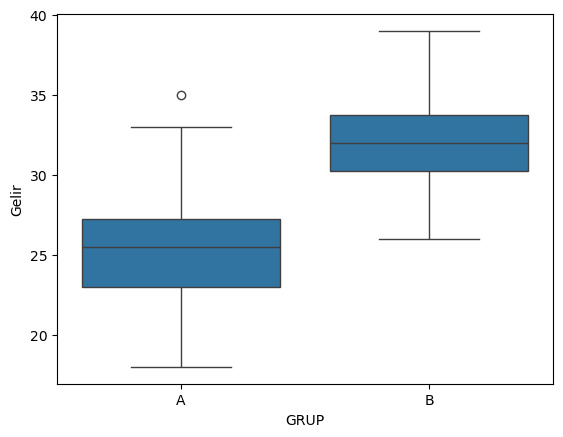

In [3]:
import seaborn as sns
sns.boxplot(x = "GRUP", y = "Gelir", data = AB);

*B ML modelinin tavsiyelerine göre alışveriş yapan müşterilerden elde edilen gelirler daha fazla görünüyor. İşte bunu bilimsel olarak AB testi ile doğrulayacağız.*

#### Varsayım Kontrolü

In [4]:
A_B.head()

,A,B
0,30,37
1,27,39
2,21,31
3,27,31
4,29,34


In [5]:
AB.head()

,Gelir,GRUP
0,30,A
1,27,A
2,21,A
3,27,A
4,29,A


In [6]:
#Normallik Varsayımı
#Burada shapiro testini A grubu ve B grubu değerleri için ayrı ayrı yapmak daha sağlıklı olacaktır.
#Bu yüzden A_B dataframe'ini kullanıyoruz
from scipy.stats import shapiro
shapiro(A_B.A)

ShapiroResult(statistic=np.float64(0.9806835544869114), pvalue=np.float64(0.8434280382628154))

*p - value değerimiz 0.05'ten büyük. H0 reddedilemiyor. Yani örnek dağılım ile normal dağılım arasında istatistiki bir fark yoktur.*

In [7]:
shapiro(A_B.B)

ShapiroResult(statistic=np.float64(0.9561261367393356), pvalue=np.float64(0.2458439374473953))

*Burada da p-value 0.05'ten büyük. H0 burda da sağlanıyor. İki grup için de Normal Varsayımı sağlamış olduk.*

In [8]:
#Varyans Homojenliği Varsayımı

*H0: Varyanslar homojendir*<br>
*H1: Varyanslar homojen değildir*<br>

In [9]:
from scipy.stats import levene
levene(A_B.A, A_B.B)

LeveneResult(statistic=np.float64(0.547597765363129), pvalue=np.float64(0.4622858588925072))

*p-value 0.05'ten büyük. H0 hipotezi reddedilemez.*

#### Hipotez Testi

In [10]:
from scipy.stats import ttest_ind
#equal_var;Varsayımların sağlandığını belirtmek için kullandığımız parametre.Yani diyoruz ki test aşamasına geçebiliriz.
ttest_ind(A_B["A"], A_B["B"], equal_var = True)

TtestResult(statistic=np.float64(-7.266590671742248), pvalue=np.float64(1.0448449912130357e-09), df=np.float64(58.0))

#### Açıklama

Yukarıdaki p-value çıktısındaki bilimsel gösterim (scientific notation). e-09 demek $\times 10^{-9}$ demek:

$$ p = 1.04 \times 10^{-9} = 0.00000000104 $$

Yani p-value aşırı küçük — alpha'dan ($0.05$) çok çok küçük.

*Yani H0 reddedildi. Yani eski A ML modelinin önerdiği ürünler sonucu elde edilen gelirler ile B ML modelinin önerdiği ürünlerden elde edilen gelirler arasında fark var. Hatta yeni olan B ML modeli daha çok gelir getiriyor. Boxplot ile bunu görmüştük ve o grafiğin doğruluğunu bilimsel olarak kanıtladık.*